In [28]:
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = "/home/export/sdurgut/scratch/alps/tracking_ALPs"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from module_VBF import read_data, raw_to_events, Delta_R
from scripts.analysis.file_helpers import ma_to_name

# ---- settings ----
GAGG = 1e-4                       # fixed coupling [GeV^-1]
MASSES = [0.01, 0.1, 1.0, 10.0]  # ALP masses [GeV]
ERA = "phase2"                    # 'phase2' or 'run3'
DATA_DIR = f"{PROJECT_ROOT}/data/cmsrun3-csvs"
NUM_EVENTS = 100000
SEED = 1234

dr_by_mass = {}
for ma in MASSES:
    np.random.seed(SEED)
    raw_events = read_data(ma_to_name(ma), num=NUM_EVENTS, data_dir=DATA_DIR)
    # single coupling -> i_g = 0
    events = raw_to_events(raw_events, gaggs=[GAGG], ma=ma, era=ERA)

    dr = np.array([
        Delta_R(ev["g1"]["eta"], ev["g2"]["eta"],
                ev["g1"]["phi"], ev["g2"]["phi"],
                ev["a"]["l"][0])              # ALP decay length at this coupling
        for ev in events
    ])
    dr = dr[np.isfinite(dr)]
    dr_by_mass[ma] = dr
    print(f"m_a = {ma:>6} GeV: {len(dr)} events, "
          f"<dR> = {dr.mean():.4f}, median = {np.median(dr):.4f}")



m_a =   0.01 GeV: 40000 events, <dR> = -255.8802, median = -22.3715
m_a =    0.1 GeV: 40000 events, <dR> = -0.1715, median = -0.0078
m_a =    1.0 GeV: 40000 events, <dR> = 0.4045, median = 0.1469
m_a =   10.0 GeV: 40000 events, <dR> = 1.6787, median = 1.1220


/home/export/sdurgut/scratch/ttHbb_SPANet/envs/notebook_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


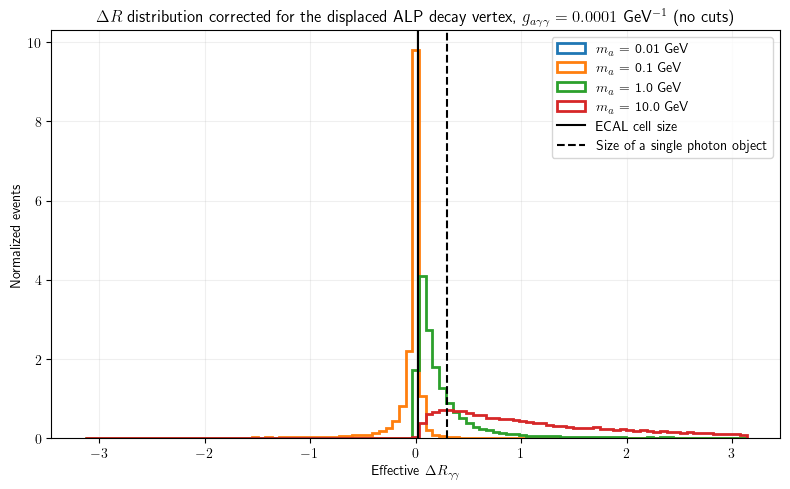

In [29]:
# ---- plot ----
bins = np.linspace(-np.pi, np.pi, 100)
plt.figure(figsize=(8, 5))
for ma in MASSES:
    plt.hist(dr_by_mass[ma], bins=bins, histtype="step", lw=2,
             density=True, label=fr"$m_a$ = {ma} GeV")

plt.xlabel(r"Effective $\Delta R_{\gamma\gamma}$")
plt.ylabel("Normalized events")
#vertical line at 0.025 with label "ECAL cell size"
plt.axvline(0.025, color='black', linestyle='-', label='ECAL cell size')
plt.axvline(0.3, color='black', linestyle='--', label='Size of a single photon object')
plt.title(fr"$\Delta R$ distribution corrected for the displaced ALP decay vertex, $g_{{a\gamma\gamma}} = {GAGG:g}$ GeV$^{{-1}}$ (no cuts)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

when the ALP decay length alp_decay_length exceeds R_ECAL, the numerator goes negative and scale becomes negative, and it's unbounded, so l_a ≫ R_ECAL gives a large negative number

In [30]:
#try flooring the scale at 0 (treat decays past the ECAL as fully merged (dR->0))

In [31]:
import sys
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = "/home/export/sdurgut/scratch/alps/tracking_ALPs"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from module_VBF import read_data, raw_to_events, Delta_R
from scripts.analysis.file_helpers import ma_to_name

# ---- settings ----
GAGG = 1e-4                       # fixed coupling [GeV^-1]
MASSES = [0.01, 0.1, 1.0, 10.0]  # ALP masses [GeV]
ERA = "phase2"                    # 'phase2' or 'run3'
DATA_DIR = f"{PROJECT_ROOT}/data/cmsrun3-csvs"
NUM_EVENTS = 100000
SEED = 1234

dr_by_mass = {}
for ma in MASSES:
    np.random.seed(SEED)
    raw_events = read_data(ma_to_name(ma), num=NUM_EVENTS, data_dir=DATA_DIR)
    # single coupling -> i_g = 0
    events = raw_to_events(raw_events, gaggs=[GAGG], ma=ma, era=ERA)

    dr = np.array([
        Delta_R(ev["g1"]["eta"], ev["g2"]["eta"],
                ev["g1"]["phi"], ev["g2"]["phi"],
                ev["a"]["l"][0])              # ALP decay length at this coupling
        for ev in events
    ])
    dr = dr[np.isfinite(dr)]
    dr = dr[dr >= 0]
    dr_by_mass[ma] = dr
    print(f"m_a = {ma:>6} GeV: {len(dr)} events, "
          f"<dR> = {dr.mean():.4f}, median = {np.median(dr):.4f}")



/tmp/ipykernel_3506538/1624603651.py:37: RuntimeWarning: Mean of empty slice
  f"<dR> = {dr.mean():.4f}, median = {np.median(dr):.4f}")
/home/export/sdurgut/scratch/ttHbb_SPANet/envs/notebook_env/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/export/sdurgut/scratch/ttHbb_SPANet/envs/notebook_env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,


m_a =   0.01 GeV: 0 events, <dR> = nan, median = nan
m_a =    0.1 GeV: 13307 events, <dR> = 0.0505, median = 0.0147
m_a =    1.0 GeV: 40000 events, <dR> = 0.4045, median = 0.1469
m_a =   10.0 GeV: 40000 events, <dR> = 1.6787, median = 1.1220


/home/export/sdurgut/scratch/ttHbb_SPANet/envs/notebook_env/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


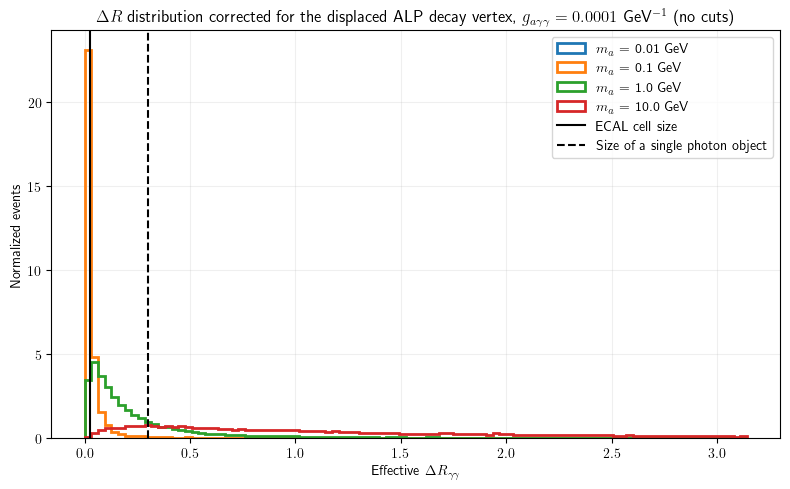

In [33]:
# ---- plot ----
bins = np.linspace(0, np.pi, 100)
plt.figure(figsize=(8, 5))
for ma in MASSES:
    plt.hist(dr_by_mass[ma], bins=bins, histtype="step", lw=2,
             density=True, label=fr"$m_a$ = {ma} GeV")

plt.xlabel(r"Effective $\Delta R_{\gamma\gamma}$")
plt.ylabel("Normalized events")
#vertical line at 0.025 with label "ECAL cell size"
plt.axvline(0.025, color='black', linestyle='-', label='ECAL cell size')
plt.axvline(0.3, color='black', linestyle='--', label='Size of a single photon object')
plt.title(fr"$\Delta R$ distribution corrected for the displaced ALP decay vertex, $g_{{a\gamma\gamma}} = {GAGG:g}$ GeV$^{{-1}}$ (no cuts)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()